In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


file_path = r"C:\Users\yildi\Desktop\tamfinans\collection_master_data_v4.csv"
df = pd.read_csv(file_path, sep=None, engine='python', encoding='utf-8-sig')

df.columns = df.columns.str.strip()

#log
print("Sütun İsimleri:", df.columns.tolist())


le = LabelEncoder()
categorical_cols = ['sector', 'tax_type', 'factoring_type', 'contact_type']

for col in categorical_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
    else:
        print(f"UYARI: {col} sütunu bulunamadı!")

scaler = StandardScaler() 
numeric_cols = ['income', 'invoice_amount', 'dpd'] 
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

#eğitim
X = df.drop(columns=[c for c in ['customer_id', 'ptp_status'] if c in df.columns])
y = df['ptp_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



Sütun İsimleri: ['customer_id', 'income', 'invoice_amount', 'dpd', 'sector', 'tax_type', 'factoring_type', 'contact_type', 'ptp_status']


In [2]:
#Problem 1: Öder mi? Ödemez mi?(Classification)

xgb_v4 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, eval_metric='logloss')
xgb_v4.fit(X_train, y_train)

predictions = xgb_v4.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy score:: {accuracy:.2f}") 
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy score:: 0.84

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89      1332
           1       0.82      0.67      0.74       668

    accuracy                           0.84      2000
   macro avg       0.84      0.80      0.81      2000
weighted avg       0.84      0.84      0.84      2000



In [3]:
# Problem 3: Risk skoru hesaplama

df['risk_score'] = xgb_v4.predict_proba(X)[:, 0] * 100

def segment_me(score):
    if score >= 80: return 'High Risk (Red)'
    elif score >= 40: return 'Medium Risk (Yellow)'
    else: return 'Low Risk (Green)'

df['risk_segment'] = df['risk_score'].apply(segment_me)


print("Risk Segment Distribution:")
print(df['risk_segment'].value_counts())

print("\nSample Risk Profile (First 5):")

cols_to_show = ['customer_id', 'risk_score', 'risk_segment']
print(df[[c for c in cols_to_show if c in df.columns]].head())

Risk Segment Distribution:
risk_segment
High Risk (Red)         5861
Low Risk (Green)        2713
Medium Risk (Yellow)    1426
Name: count, dtype: int64

Sample Risk Profile (First 5):
  customer_id  risk_score          risk_segment
0      CUST-0   20.726818      Low Risk (Green)
1      CUST-1   86.737473       High Risk (Red)
2      CUST-2   15.982241      Low Risk (Green)
3      CUST-3   71.252403  Medium Risk (Yellow)
4      CUST-4   81.680634       High Risk (Red)


In [4]:
# Problem 2: Ne kadar süregecicek? (Regression)
drop_reg_cols = ['customer_id', 'ptp_status', 'risk_segment', 'dpd']
X_reg = df.drop(columns=[c for c in drop_reg_cols if c in df.columns])
y_reg = df['dpd'] 


X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


xgb_reg = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

xgb_reg.fit(X_train_reg, y_train_reg)


y_pred_reg = xgb_reg.predict(X_test_reg)

r2 = r2_score(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)

print(f"Enhanced Regression R2 Score: {r2:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")

# Feature Importance (En çok ne etkiliyor? buradan bakıcaz)
importances = pd.Series(xgb_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)
print("\nTop Factors for Delay Prediction:")
print(importances)

Enhanced Regression R2 Score: 0.53
Mean Absolute Error (MAE): 0.56 days

Top Factors for Delay Prediction:
risk_score        0.517929
invoice_amount    0.122451
income            0.114126
sector            0.103956
tax_type          0.048348
contact_type      0.047350
factoring_type    0.045840
dtype: float32


In [5]:
# Problem 4: Ne zaman aramalıyım? (Decision)

def ai_collector_agent(row):
    
    if row['risk_score'] >= 85:
        return "CRITICAL: Urgent Call by Senior Collector + Legal Warning"
    elif row['risk_score'] >= 60:
        return "WARNING: Automated AI Voice Call + Payment Reminder"
    elif row['risk_score'] >= 30:
        return "FOLLOW-UP: Send SMS & Email Reminder"
    else:
        return "NORMAL: Routine Monitoring"


df['ai_action_plan'] = df.apply(ai_collector_agent, axis=1)


action_summary = df[['customer_id', 'risk_score', 'dpd', 'ai_action_plan']].head(10)

print("AI Collector Agent - Action Plan Summary (First 10 Customers):")
print(action_summary.to_string(index=False))

print("\nAction Plan Distribution:")
print(df['ai_action_plan'].value_counts())

AI Collector Agent - Action Plan Summary (First 10 Customers):
customer_id  risk_score       dpd                                            ai_action_plan
     CUST-0   20.726818 -1.464695                                NORMAL: Routine Monitoring
     CUST-1   86.737473  0.646675 CRITICAL: Urgent Call by Senior Collector + Legal Warning
     CUST-2   15.982241 -0.936853                                NORMAL: Routine Monitoring
     CUST-3   71.252403 -1.313883       WARNING: Automated AI Voice Call + Payment Reminder
     CUST-4   81.680634 -1.012259       WARNING: Automated AI Voice Call + Payment Reminder
     CUST-5   91.977966 -0.635228 CRITICAL: Urgent Call by Senior Collector + Legal Warning
     CUST-6   80.332718  0.797487       WARNING: Automated AI Voice Call + Payment Reminder
     CUST-7   84.968742  1.023705       WARNING: Automated AI Voice Call + Payment Reminder
     CUST-8   87.547859  0.797487 CRITICAL: Urgent Call by Senior Collector + Legal Warning
     CUST-9   18.

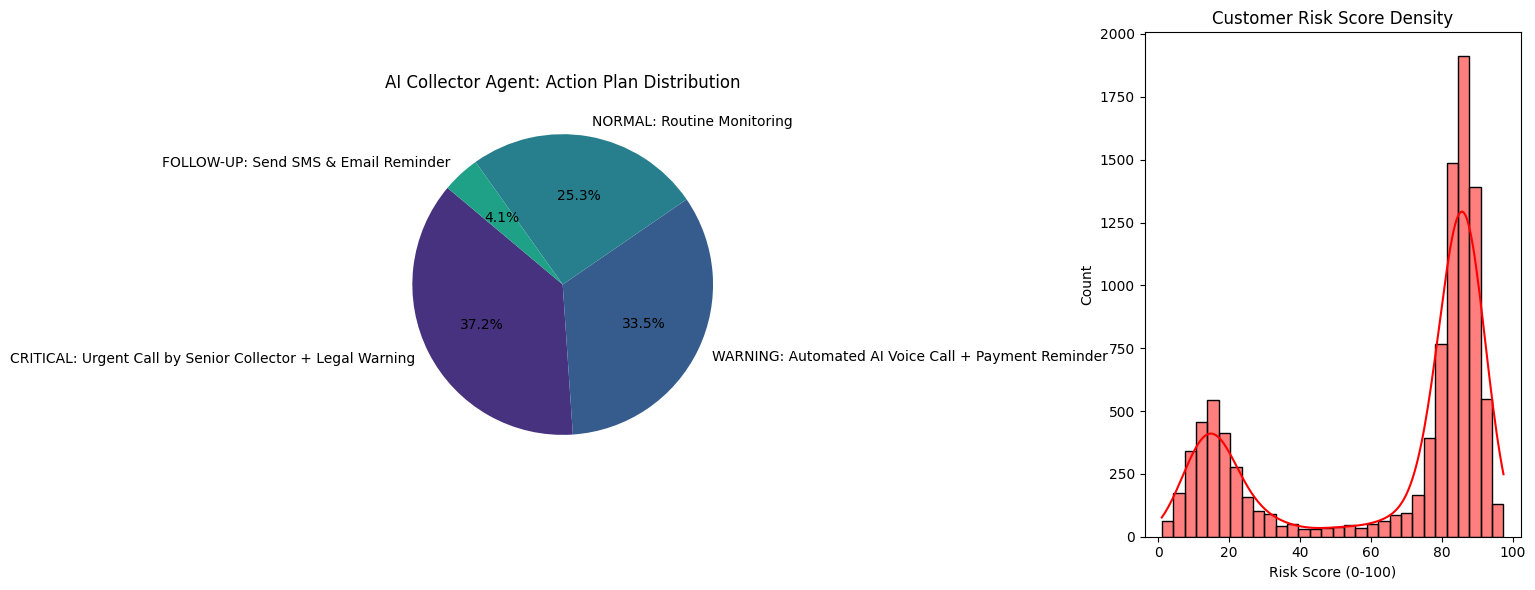

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
df['ai_action_plan'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('viridis'), startangle=140)
plt.title('AI Collector Agent: Action Plan Distribution')
plt.ylabel('')


plt.subplot(1, 2, 2)
sns.histplot(df['risk_score'], bins=30, kde=True, color='red')
plt.title('Customer Risk Score Density')
plt.xlabel('Risk Score (0-100)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
import joblib

# 1.Sınıflandırma Modeli (Öder mi?)
joblib.dump(xgb_v4, r"C:\Users\yildi\Desktop\tamfinans\tahmin_modeli.pkl")

# 2.Regresyon Modeli (Kaç gün gecikir?)
joblib.dump(xgb_reg, r"C:\Users\yildi\Desktop\tamfinans\gecikme_modeli.pkl")

# 3.Encoding ve Scaling
joblib.dump(le, r"C:\Users\yildi\Desktop\tamfinans\label_encoder.pkl")
joblib.dump(scaler, r"C:\Users\yildi\Desktop\tamfinans\scaler.pkl")

['C:\\Users\\yildi\\Desktop\\tamfinans\\scaler.pkl']